ADVANCED OBJECT DETECTION & COUNTING SYSTEM

✓ YOLOv8 library found

📤 Upload your image file:


Saving five-examples-city-vector-illustration_443748-935.webp to five-examples-city-vector-illustration_443748-935 (2).webp
✓ Image uploaded: five-examples-city-vector-illustration_443748-935 (2).webp
✓ Image loaded: five-examples-city-vector-illustration_443748-935 (2).webp
STAGE 1: ORIGINAL IMAGE


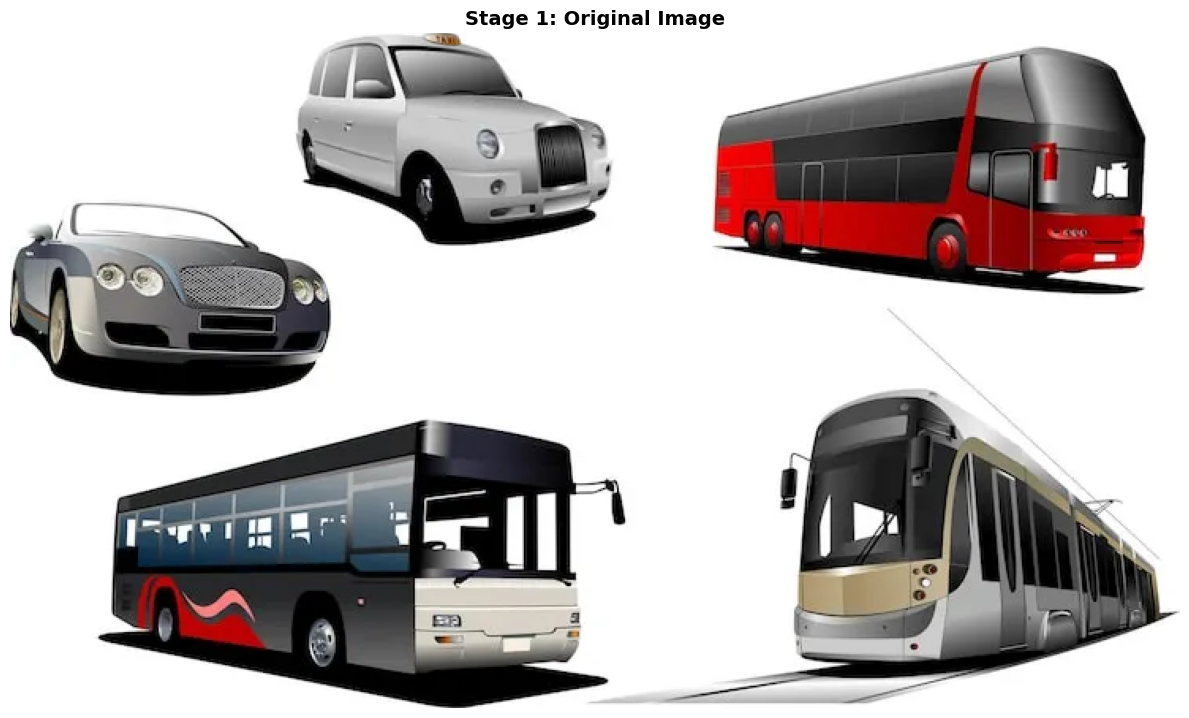


 IMAGE PROPERTIES:
   - Height: 427 pixels
   - Width: 740 pixels
   - Channels: 3 (BGR)
   - Total pixels: 315980
  Latency: 276.9639 ms
STAGE 2: LOAD YOLOv8 MODEL

 Loading YOLOv8 Nano model...
✓ YOLOv8n model loaded successfully

 MODEL INFORMATION:
   - Model variant: Nano (yolov8n)
   - Trainable parameters: ~3.2M
   - Image size: 640×640
   - Confidence threshold: 0.5 (50%)
  Latency: 55.2008 ms
STAGE 3: INFERENCE (PREDICTION)

 Running YOLOv8 detection...
✓ Inference complete

 INFERENCE DETAILS:
   - Inference time: 63.3562 ms
   - FPS: 15.78 frames/second
   - Input size: 640×640 (auto-scaled)
   - Confidence threshold: 0.5
  Latency: 63.3562 ms
STAGE 4: EXTRACT DETECTIONS


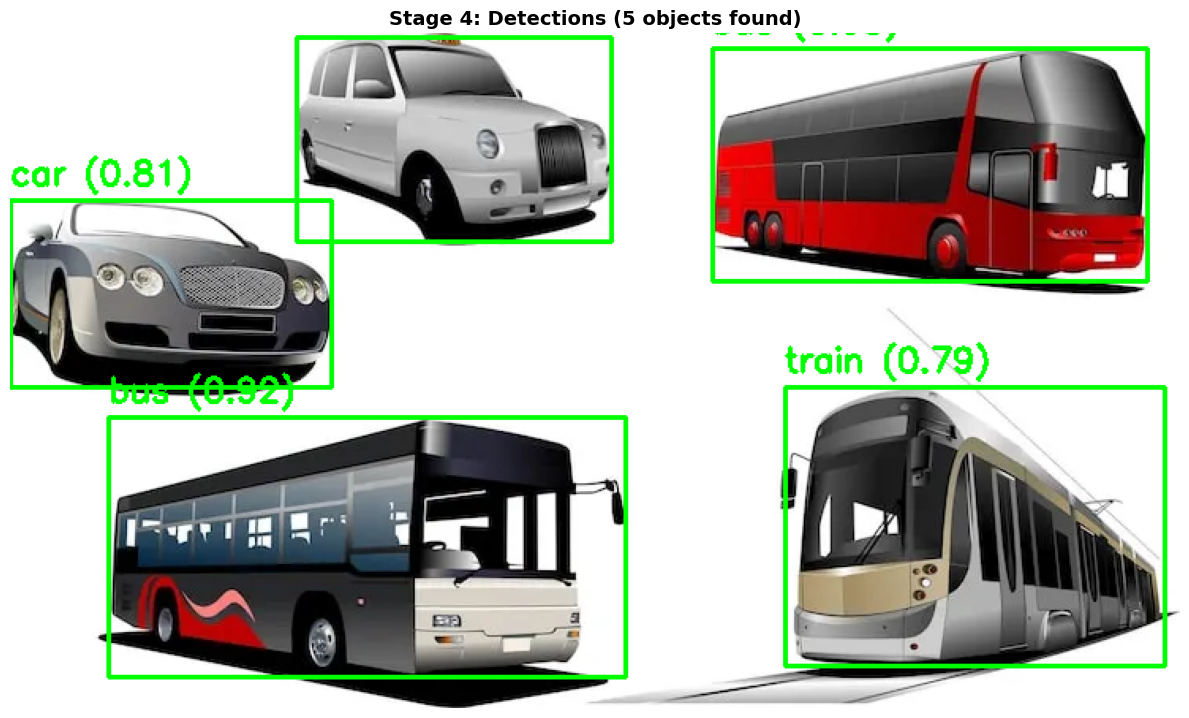


 EXTRACTION RESULTS:
   - Total detections: 5
  Latency: 1.7807 ms
STAGE 5: OBJECT CLASSIFICATION & GROUPING


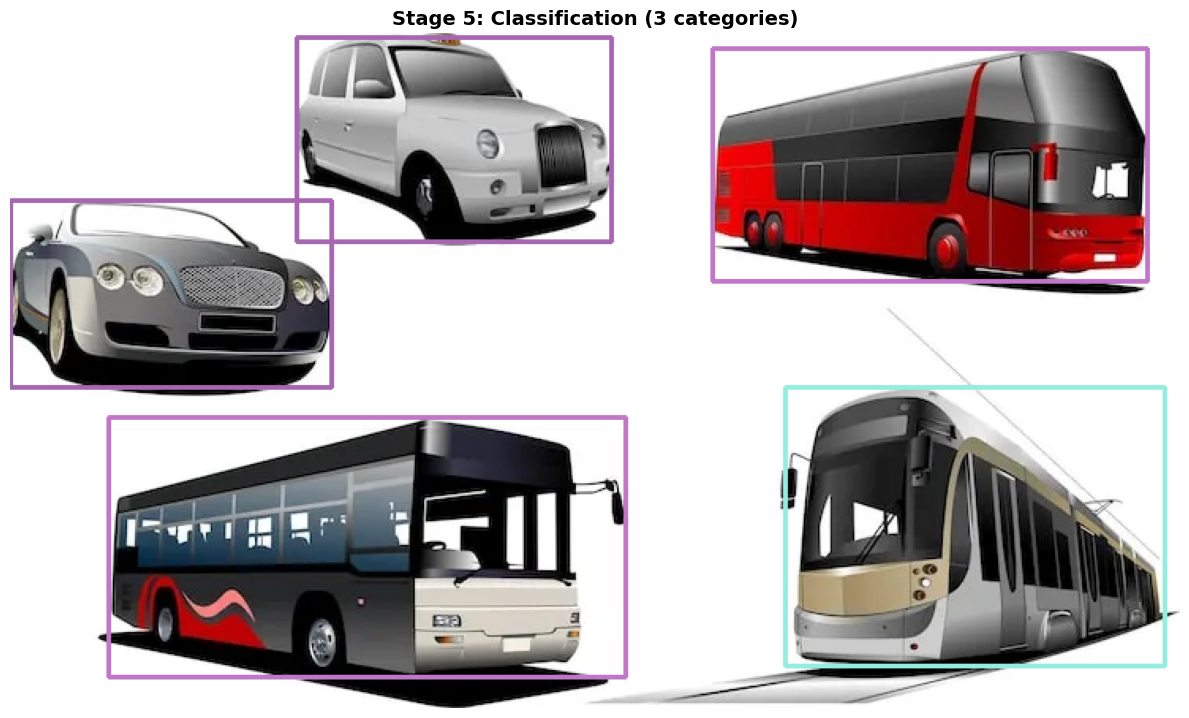


 CLASSIFICATION RESULTS:
   - Unique classes found: 3
   - bus: 2 objects
   - car: 2 objects
   - train: 1 objects
  Latency: 0.1495 ms
STAGE 6: FINAL COUNTING & STATISTICS


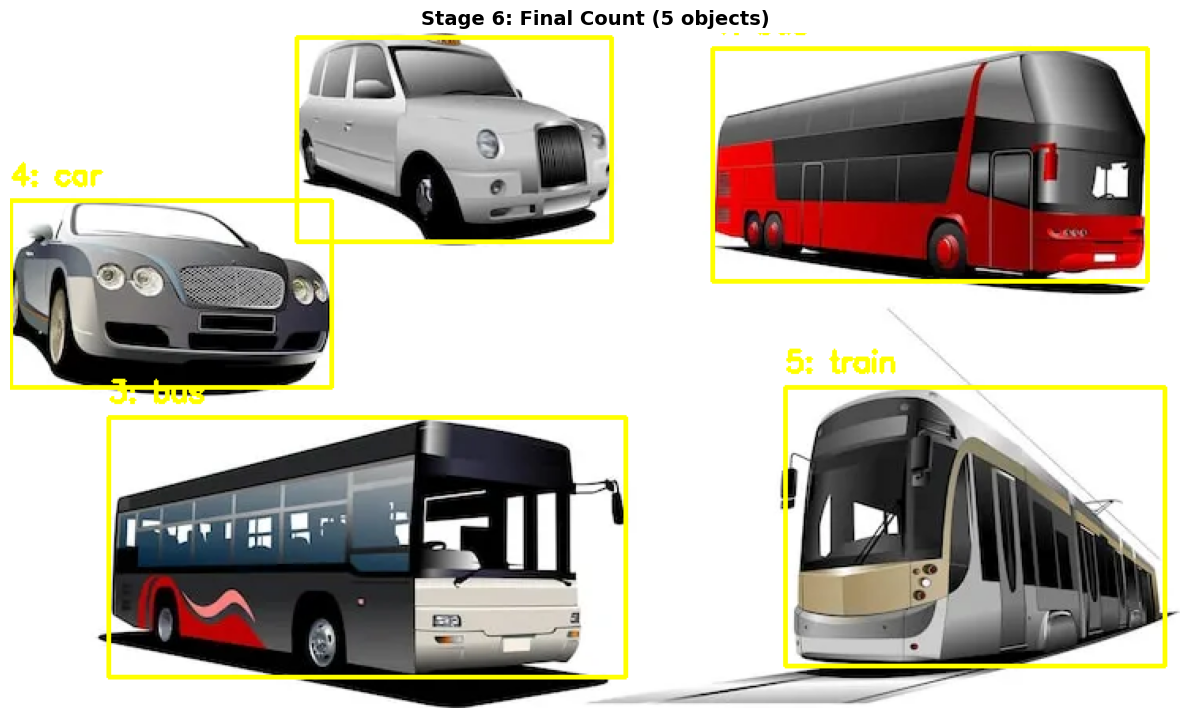


 COUNTING RESULTS:
   - Total objects detected: 5
   - BUS: 2
   - CAR: 2
   - TRAIN: 1
DETAILED DETECTION DATA

 INDIVIDUAL OBJECT ANALYSIS:

Object 1:
   - Class: bus
   - Confidence: 92.69%
   - Bounding Box: (444, 10) to (719, 157)
   - Width: 275 pixels
   - Height: 147 pixels
   - Area: 40425 pixels²
   - Center: (581, 83)

Object 2:
   - Class: car
   - Confidence: 92.57%
   - Bounding Box: (181, 3) to (380, 132)
   - Width: 199 pixels
   - Height: 129 pixels
   - Area: 25671 pixels²
   - Center: (280, 67)

Object 3:
   - Class: bus
   - Confidence: 91.67%
   - Bounding Box: (62, 243) to (389, 407)
   - Width: 327 pixels
   - Height: 164 pixels
   - Area: 53628 pixels²
   - Center: (225, 325)

Object 4:
   - Class: car
   - Confidence: 80.81%
   - Bounding Box: (0, 106) to (203, 224)
   - Width: 203 pixels
   - Height: 118 pixels
   - Area: 23954 pixels²
   - Center: (101, 165)

Object 5:
   - Class: train
   - Confidence: 78.80%
   - Bounding Box: (490, 224) to (730, 400)
   -

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import time
print("ADVANCED OBJECT DETECTION & COUNTING SYSTEM")
# ============================================================
# INSTALL ULTRALYTICS IF NOT PRESENT
# ============================================================
try:
    from ultralytics import YOLO
    print("\n✓ YOLOv8 library found")
except (ImportError, ModuleNotFoundError):
    print("\n⚠️  Installing YOLOv8...")
    os.system("pip install --upgrade ultralytics torch torchvision")
    print("\n✓ Installation complete. Restarting import...")
    import importlib
    import sys
    if 'ultralytics' in sys.modules:
        del sys.modules['ultralytics']
    from ultralytics import YOLO
    print("✓ YOLOv8 imported successfully")

# ============================================================
# TIMING AND METRICS INITIALIZATION
# ============================================================
start_total = time.time()
metrics = {
    'stage_times': {},
    'latencies': {}
}

# Try to get image from user
image_path = None

try:
    from google.colab import files
    print("\n📤 Upload your image file:")
    uploaded = files.upload()
    if uploaded:
        image_path = list(uploaded.keys())[0]
        print(f"✓ Image uploaded: {image_path}")
except:
    image_path = input("\n📁 Enter image path (or press Enter for demo): ").strip()
    if not image_path:
        image_path = None

# Load image
if image_path and os.path.exists(image_path):
    img = cv2.imread(image_path)
    print(f"✓ Image loaded: {image_path}")
else:
    print("❌ Image not found. Using demo image...")
    # Create demo image with various objects
    img = np.ones((600, 800, 3), dtype=np.uint8) * 200
    # Add some shapes
    cv2.circle(img, (100, 100), 40, (0, 0, 255), -1)
    cv2.circle(img, (300, 150), 50, (0, 255, 0), -1)
    cv2.rectangle(img, (450, 100), (550, 200), (255, 0, 0), -1)
    cv2.rectangle(img, (650, 120), (750, 220), (0, 255, 255), -1)

# ============================================================
# STAGE 1: ORIGINAL IMAGE
# ============================================================
print("STAGE 1: ORIGINAL IMAGE")
stage1_start = time.time()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Stage 1: Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

stage1_time = time.time() - stage1_start
metrics['stage_times']['Stage 1: Original'] = stage1_time

print(f"\n IMAGE PROPERTIES:")
print(f"   - Height: {img.shape[0]} pixels")
print(f"   - Width: {img.shape[1]} pixels")
print(f"   - Channels: {img.shape[2]} (BGR)")
print(f"   - Total pixels: {img.shape[0] * img.shape[1]}")
print(f"  Latency: {stage1_time*1000:.4f} ms")

# ============================================================
# STAGE 2: LOAD YOLOV8 MODEL
# ============================================================
print("STAGE 2: LOAD YOLOv8 MODEL")
stage2_start = time.time()

print("\n Loading YOLOv8 Nano model...")
model = YOLO('yolov8n.pt')  # nano model
print("✓ YOLOv8n model loaded successfully")

stage2_time = time.time() - stage2_start
metrics['stage_times']['Stage 2: Model Load'] = stage2_time

print(f"\n MODEL INFORMATION:")
print(f"   - Model variant: Nano (yolov8n)")
print(f"   - Trainable parameters: ~3.2M")
print(f"   - Image size: 640×640")
print(f"   - Confidence threshold: 0.5 (50%)")
print(f"  Latency: {stage2_time*1000:.4f} ms")

# ============================================================
# STAGE 3: INFERENCE / PREDICTION
# ============================================================

print("STAGE 3: INFERENCE (PREDICTION)")

stage3_start = time.time()

print("\n Running YOLOv8 detection...")
results = model(img, conf=0.5, verbose=False)
stage3_time = time.time() - stage3_start

print("✓ Inference complete")
metrics['stage_times']['Stage 3: Inference'] = stage3_time

print(f"\n INFERENCE DETAILS:")
print(f"   - Inference time: {stage3_time*1000:.4f} ms")
print(f"   - FPS: {1/stage3_time:.2f} frames/second")
print(f"   - Input size: 640×640 (auto-scaled)")
print(f"   - Confidence threshold: 0.5")
print(f"  Latency: {stage3_time*1000:.4f} ms")

# ============================================================
# STAGE 4: EXTRACT DETECTIONS
# ============================================================

print("STAGE 4: EXTRACT DETECTIONS")

stage4_start = time.time()

detection_img = img.copy()
detections = []

# Get class names
class_names = model.names

if len(results) > 0:
    result = results[0]
    boxes = result.boxes

    for idx, box in enumerate(boxes):
        # Extract box coordinates
        x1, y1, x2, y2 = box.xyxy[0]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        # Extract confidence
        conf = box.conf[0]

        # Extract class
        cls = int(box.cls[0])
        class_name = class_names[cls]

        # Calculate dimensions
        width = x2 - x1
        height = y2 - y1
        area = width * height

        # Draw bounding box
        cv2.rectangle(detection_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Draw label
        label = f"{class_name} ({conf:.2f})"
        cv2.putText(detection_img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        detections.append({
            'id': idx + 1,
            'class': class_name,
            'confidence': float(conf),
            'bbox': (x1, y1, x2, y2),
            'width': width,
            'height': height,
            'area': area,
            'center': ((x1 + x2) // 2, (y1 + y2) // 2)
        })

stage4_time = time.time() - stage4_start
metrics['stage_times']['Stage 4: Extract'] = stage4_time

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(detection_img, cv2.COLOR_BGR2RGB))
plt.title(f'Stage 4: Detections ({len(detections)} objects found)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\n EXTRACTION RESULTS:")
print(f"   - Total detections: {len(detections)}")
print(f"  Latency: {stage4_time*1000:.4f} ms")

# ============================================================
# STAGE 5: OBJECT CLASSIFICATION & GROUPING
# ============================================================

print("STAGE 5: OBJECT CLASSIFICATION & GROUPING")

stage5_start = time.time()

# Group by class
class_groups = {}
for det in detections:
    cls = det['class']
    if cls not in class_groups:
        class_groups[cls] = []
    class_groups[cls].append(det)

stage5_time = time.time() - stage5_start

# Display grouped image
classified_img = img.copy()
colors = {cls: (np.random.randint(100, 255), np.random.randint(100, 255),
                np.random.randint(100, 255)) for cls in class_groups.keys()}

for cls, dets in class_groups.items():
    color = colors[cls]
    for det in dets:
        x1, y1, x2, y2 = det['bbox']
        cv2.rectangle(classified_img, (x1, y1), (x2, y2), color, 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(classified_img, cv2.COLOR_BGR2RGB))
plt.title(f'Stage 5: Classification ({len(class_groups)} categories)',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\n CLASSIFICATION RESULTS:")
print(f"   - Unique classes found: {len(class_groups)}")
for cls, dets in class_groups.items():
    print(f"   - {cls}: {len(dets)} objects")
print(f"  Latency: {stage5_time*1000:.4f} ms")

# ============================================================
# STAGE 6: FINAL COUNTING & STATISTICS
# ============================================================

print("STAGE 6: FINAL COUNTING & STATISTICS")

stage6_start = time.time()

# Create final annotated image
final_img = img.copy()
for det in detections:
    x1, y1, x2, y2 = det['bbox']
    cv2.rectangle(final_img, (x1, y1), (x2, y2), (0, 255, 255), 2)
    label = f"{det['id']}: {det['class']}"
    cv2.putText(final_img, label, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title(f'Stage 6: Final Count ({len(detections)} objects)',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

stage6_time = time.time() - stage6_start
metrics['stage_times']['Stage 6: Final Count'] = stage6_time

print(f"\n COUNTING RESULTS:")
print(f"   - Total objects detected: {len(detections)}")
for cls, count in {cls: len(dets) for cls, dets in class_groups.items()}.items():
    print(f"   - {cls.upper()}: {count}")

# ============================================================
# DETAILED OBJECT DATA
# ============================================================

print("DETAILED DETECTION DATA")


if len(detections) > 0:
    print(f"\n INDIVIDUAL OBJECT ANALYSIS:\n")

    for det in detections:
        print(f"Object {det['id']}:")
        print(f"   - Class: {det['class']}")
        print(f"   - Confidence: {det['confidence']:.2%}")
        print(f"   - Bounding Box: ({det['bbox'][0]}, {det['bbox'][1]}) to " +
              f"({det['bbox'][2]}, {det['bbox'][3]})")
        print(f"   - Width: {det['width']} pixels")
        print(f"   - Height: {det['height']} pixels")
        print(f"   - Area: {det['area']} pixels²")
        print(f"   - Center: {det['center']}")
        print()

    # Statistics
    print("\n SUMMARY STATISTICS:\n")

    for cls in class_groups.keys():
        cls_dets = [d for d in detections if d['class'] == cls]
        areas = [d['area'] for d in cls_dets]
        confidences = [d['confidence'] for d in cls_dets]

        print(f"{cls.upper()}:")
        print(f"   Count: {len(cls_dets)}")
        print(f"   Area (pixels²):")
        print(f"      - Min: {min(areas)}")
        print(f"      - Max: {max(areas)}")
        print(f"      - Mean: {np.mean(areas):.2f}")
        print(f"   Confidence:")
        print(f"      - Min: {min(confidences):.2%}")
        print(f"      - Max: {max(confidences):.2%}")
        print(f"      - Mean: {np.mean(confidences):.2%}")
        print()

print(f"  Latency: {stage6_time*1000:.4f} ms")

# ============================================================
# PERFORMANCE METRICS
# ============================================================

print("PERFORMANCE METRICS & INFERENCE TIME")


total_time = time.time() - start_total

print(f"\n  STAGE-WISE LATENCY:")
for stage, latency in metrics['stage_times'].items():
    latency_ms = latency * 1000
    percent = (latency / total_time) * 100
    print(f"   {stage}: {latency_ms:.4f} ms ({percent:.1f}%)")

print(f"\n OVERALL TIMING:")
print(f"   - Total Execution Time: {total_time*1000:.4f} ms")
print(f"   - Inference Time: {stage3_time*1000:.4f} ms")
print(f"   - Model Load Time: {stage2_time*1000:.4f} ms")
print(f"   - Post-processing: {(stage4_time + stage5_time + stage6_time)*1000:.4f} ms")

